In [1]:
# Базовые библиотеки
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

import json

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [2]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [3]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(f'artifacts/figures/{title + ' (loss)' if title else 'loss'}.png')
    plt.show()


    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig(f'artifacts/figures/{title + " (accuracy)" if title else "accuracy"}.png')
    plt.show()

In [4]:
# Трансформации: ToTensor и Normalize
# FashionMNIST уже в [0,1] после ToTensor, но нормализация помогает обучению.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_full = torchvision.datasets.EMNIST(
    root="./data",
    split="balanced",
    train=True,
    download=True,
    transform=transform,
)

test_ds = torchvision.datasets.EMNIST(
    root="./data",
    split="balanced",
    train=False,
    download=True,
    transform=transform,
)

class_names = train_full.classes
print("classes:", class_names)
print("len classes:", len(class_names))
print("train size:", len(train_full))
print("test size:", len(test_ds))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
len classes: 47
train size: 112800
test size: 18800


In [5]:
# Размер батча подстроим под наличие GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)
print("x_batch min/max:", x_batch.min().item(), x_batch.max().item())
print("y_batch min/max:", y_batch.min().item(), y_batch.max().item())
print("unique labels in batch:", torch.unique(y_batch))

x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64
x_batch min/max: -1.0 1.0
y_batch min/max: 0 46
unique labels in batch: tensor([ 0,  2,  3,  4,  7,  8,  9, 10, 11, 12, 13, 14, 17, 18, 19, 23, 24, 28,
        29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 46])


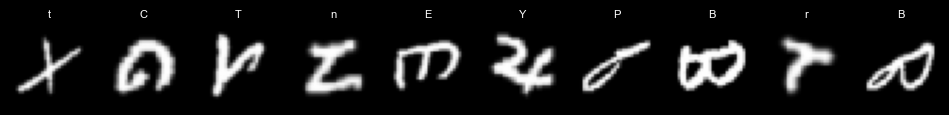

In [6]:
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [7]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([64, 47])


In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [9]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [10]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

e1
epoch 01/10 | train loss=1.6071, acc=0.5487 | val loss=1.1819, acc=0.6561
epoch 02/10 | train loss=1.0319, acc=0.6924 | val loss=0.9405, acc=0.7161
epoch 03/10 | train loss=0.8781, acc=0.7316 | val loss=0.8411, acc=0.7477
epoch 04/10 | train loss=0.8022, acc=0.7515 | val loss=0.8056, acc=0.7546
epoch 05/10 | train loss=0.7505, acc=0.7662 | val loss=0.7635, acc=0.7644
epoch 06/10 | train loss=0.7165, acc=0.7751 | val loss=0.7513, acc=0.7664
epoch 07/10 | train loss=0.6904, acc=0.7814 | val loss=0.7321, acc=0.7757
epoch 08/10 | train loss=0.6697, acc=0.7876 | val loss=0.7130, acc=0.7829
epoch 09/10 | train loss=0.6513, acc=0.7919 | val loss=0.7054, acc=0.7800
epoch 10/10 | train loss=0.6391, acc=0.7943 | val loss=0.6852, acc=0.7890
e2
epoch 01/10 | train loss=2.1351, acc=0.3921 | val loss=1.2738, acc=0.6420
epoch 02/10 | train loss=1.5968, acc=0.5264 | val loss=1.1154, acc=0.6806
epoch 03/10 | train loss=1.4875, acc=0.5549 | val loss=1.0512, acc=0.6883
epoch 04/10 | train loss=1.4337,

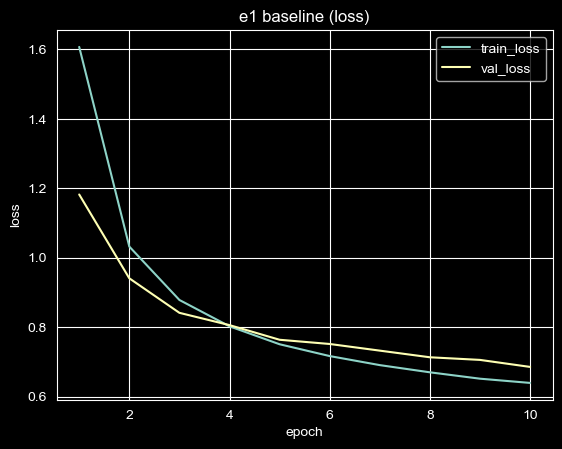

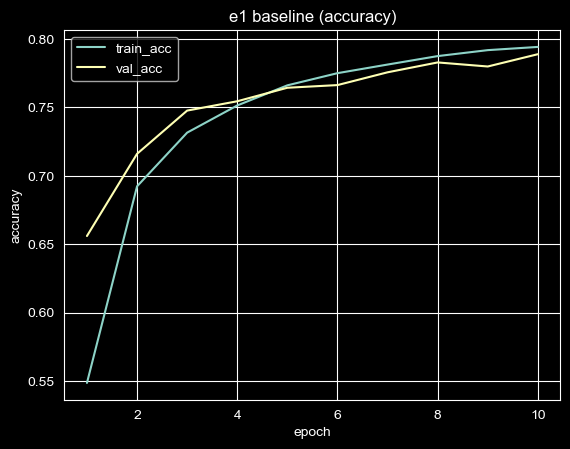

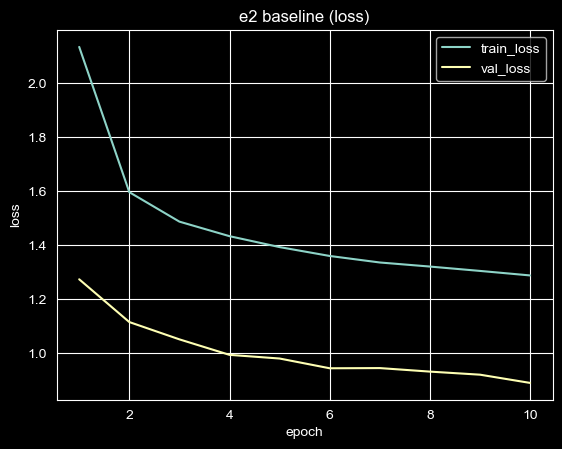

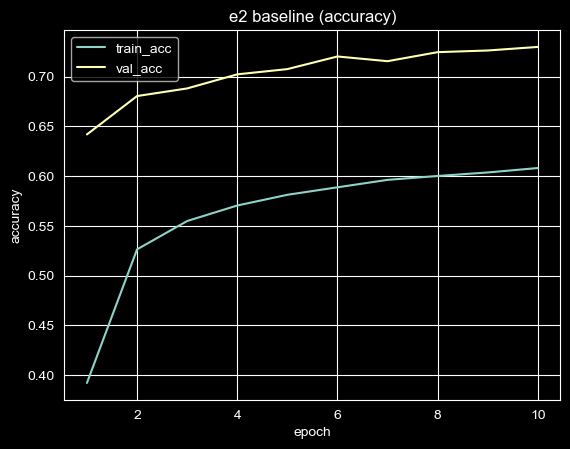

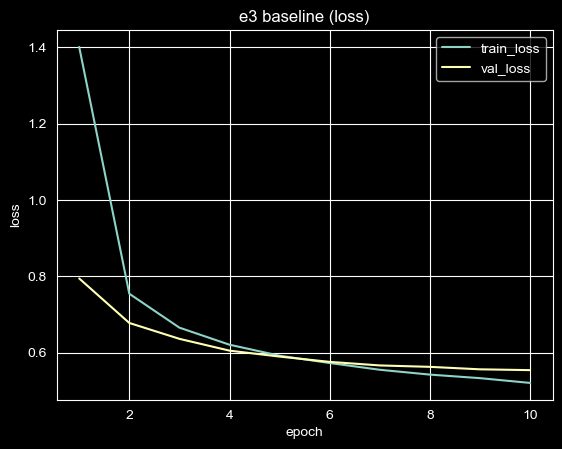

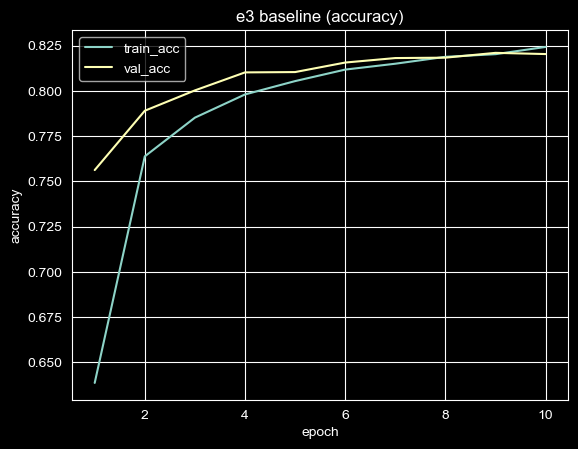

In [11]:
# Baseline: без Dropout и BatchNorm
set_seed(42)
e1 = MLP(hidden_dims=(64, 32), dropout_p=0.0, use_batchnorm=False).to(device)
e2 = MLP(hidden_dims=(64, 32), dropout_p=0.2, use_batchnorm=False).to(device)
e3 = MLP(hidden_dims=(64, 32), dropout_p=0.0, use_batchnorm=True).to(device)



criterion = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(e1.parameters(), lr=1e-3)
optimizer2 = optim.Adam(e2.parameters(), lr=1e-3)
optimizer3 = optim.Adam(e3.parameters(), lr=1e-3)

print('e1')
e1_baseline = fit(
    e1, train_loader, val_loader,
    optimizer1, criterion, device,
    epochs=10,
    early_stopping=None
)
print('e2')
e2_baseline = fit(
    e2, train_loader, val_loader,
    optimizer2, criterion, device,
    epochs=10,
    early_stopping=None
)
print('e3')
e3_baseline = fit(
    e3, train_loader, val_loader,
    optimizer3, criterion, device,
    epochs=10,
    early_stopping=None
)

plot_history(e1_baseline, title="e1 baseline")
plot_history(e2_baseline, title="e2 baseline")
plot_history(e3_baseline, title="e3 baseline")

In [12]:
_, val_acc_e2 = evaluate(e2, val_loader, criterion, device)
_, val_acc_e3 = evaluate(e3, val_loader, criterion, device)
if val_acc_e2 >= val_acc_e3:
    print('e2 лучше')
    e4 = MLP(hidden_dims=(64, 32), dropout_p=0.2, use_batchnorm=False).to(device)
else:
    print('е3 лучше')
    e4 = MLP(hidden_dims=(64, 32), dropout_p=0.0, use_batchnorm=True).to(device)

optimizer4 = optim.Adam(e4.parameters(), lr=1e-3)

early_stopping = EarlyStopping(patience=3)

e4_baseline = fit(
    e4, train_loader, val_loader,
    optimizer4, criterion, device,
    epochs=50,
    early_stopping=early_stopping
)





е3 лучше
epoch 01/50 | train loss=1.4233, acc=0.6314 | val loss=0.8334, acc=0.7469
epoch 02/50 | train loss=0.7697, acc=0.7587 | val loss=0.6942, acc=0.7854
epoch 03/50 | train loss=0.6791, acc=0.7824 | val loss=0.6468, acc=0.7962
epoch 04/50 | train loss=0.6327, acc=0.7947 | val loss=0.6190, acc=0.8020
epoch 05/50 | train loss=0.6006, acc=0.8029 | val loss=0.6075, acc=0.8058
epoch 06/50 | train loss=0.5785, acc=0.8092 | val loss=0.5895, acc=0.8106
epoch 07/50 | train loss=0.5639, acc=0.8132 | val loss=0.5849, acc=0.8146
epoch 08/50 | train loss=0.5494, acc=0.8168 | val loss=0.5732, acc=0.8141
epoch 09/50 | train loss=0.5362, acc=0.8197 | val loss=0.5745, acc=0.8186
epoch 10/50 | train loss=0.5274, acc=0.8217 | val loss=0.5645, acc=0.8196
epoch 11/50 | train loss=0.5160, acc=0.8249 | val loss=0.5679, acc=0.8174
epoch 12/50 | train loss=0.5100, acc=0.8270 | val loss=0.5550, acc=0.8205
epoch 13/50 | train loss=0.5040, acc=0.8290 | val loss=0.5570, acc=0.8197
epoch 14/50 | train loss=0.49

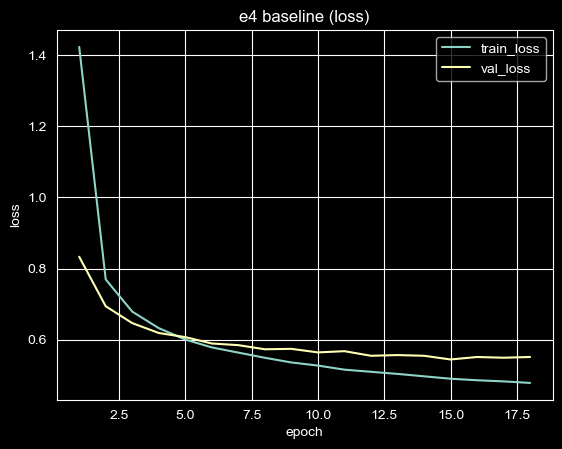

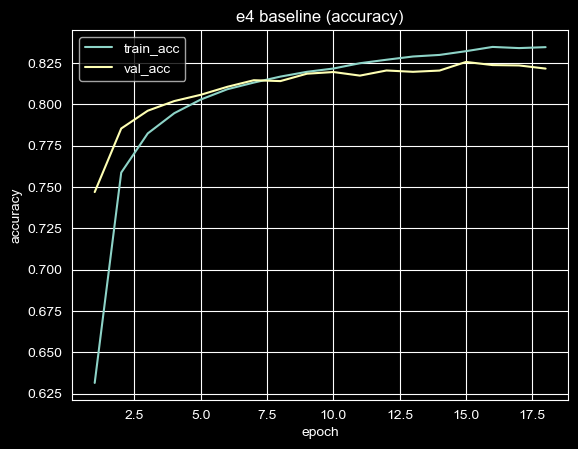

In [13]:
plot_history(e4_baseline, title="e4 baseline")

o1
epoch 01/8 | train loss=1.3045, acc=0.6084 | val loss=1.0009, acc=0.7009
epoch 02/8 | train loss=1.0032, acc=0.6903 | val loss=0.8793, acc=0.7308
epoch 03/8 | train loss=0.9391, acc=0.7089 | val loss=0.8743, acc=0.7303
epoch 04/8 | train loss=0.9045, acc=0.7158 | val loss=0.8433, acc=0.7345
epoch 05/8 | train loss=0.8769, acc=0.7239 | val loss=0.8283, acc=0.7442
epoch 06/8 | train loss=0.8599, acc=0.7297 | val loss=0.7826, acc=0.7443
epoch 07/8 | train loss=0.8398, acc=0.7363 | val loss=0.8166, acc=0.7388
epoch 08/8 | train loss=0.8220, acc=0.7406 | val loss=0.7802, acc=0.7569
o2
epoch 01/8 | train loss=3.6700, acc=0.0898 | val loss=3.4906, acc=0.1582
epoch 02/8 | train loss=3.3936, acc=0.2056 | val loss=3.2969, acc=0.2519
epoch 03/8 | train loss=3.2316, acc=0.2810 | val loss=3.1450, acc=0.3198
epoch 04/8 | train loss=3.0970, acc=0.3423 | val loss=3.0213, acc=0.3763
epoch 05/8 | train loss=2.9754, acc=0.3896 | val loss=2.8981, acc=0.4202
epoch 06/8 | train loss=2.8603, acc=0.4312 | 

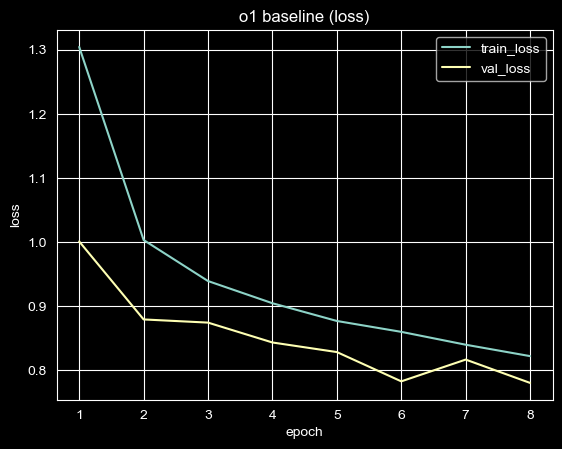

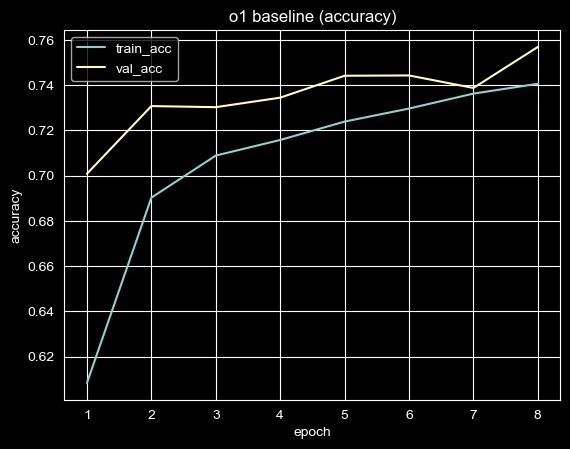

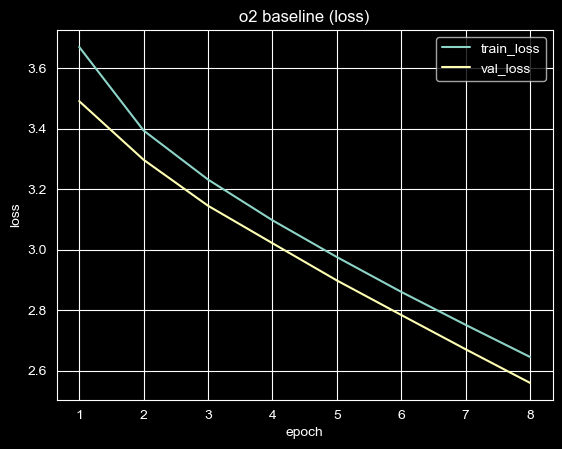

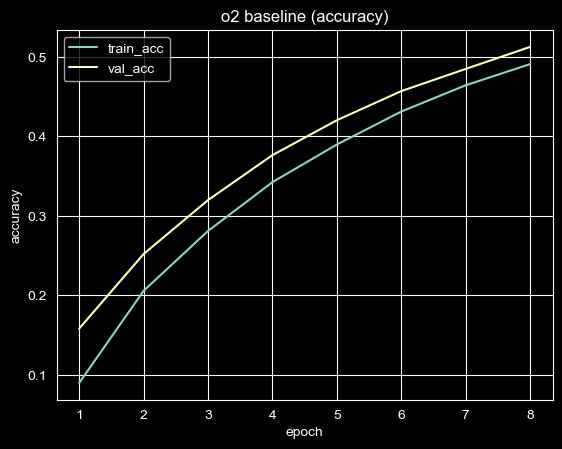

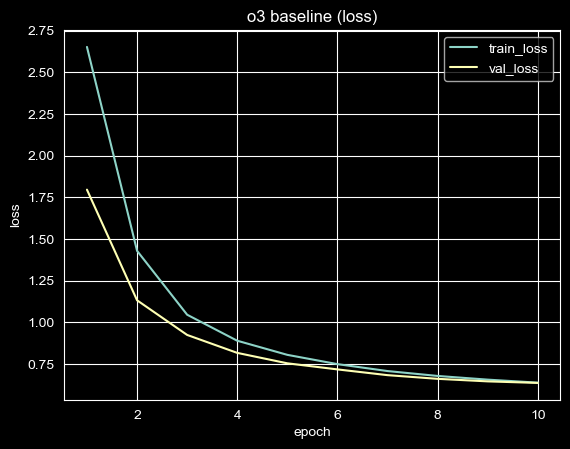

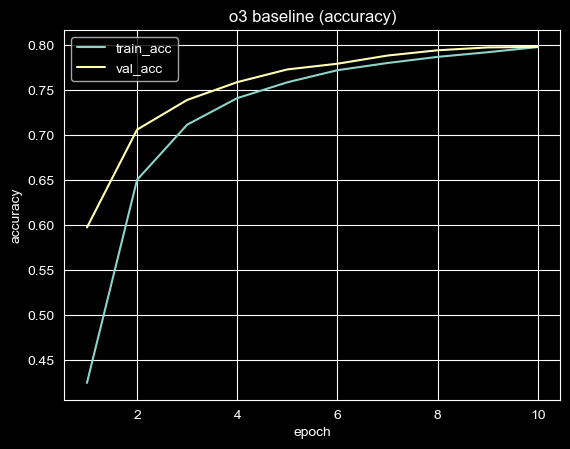

In [14]:
o1 = MLP(hidden_dims=(64, 32), dropout_p=0.0, use_batchnorm=True).to(device)
o2 = MLP(hidden_dims=(64, 32), dropout_p=0.0, use_batchnorm=True).to(device)
o3 = MLP(hidden_dims=(64, 32), dropout_p=0.0, use_batchnorm=True).to(device)

optimizer_o1 = optim.Adam(o1.parameters(), lr=1e-1)
optimizer_o2 = optim.Adam(o2.parameters(), lr=1e-5)
optimizer_o3 = optim.SGD(o3.parameters(), momentum=0.9, weight_decay=1e-4, lr=1e-3)

print('o1')
o1_baseline = fit(
    o1, train_loader, val_loader,
    optimizer_o1, criterion, device,
    epochs=8,
    early_stopping=None
)
print('o2')
o2_baseline = fit(
    o2, train_loader, val_loader,
    optimizer_o2, criterion, device,
    epochs=8,
    early_stopping=None
)
print('o3')
o3_baseline = fit(
    o3, train_loader, val_loader,
    optimizer_o3, criterion, device,
    epochs=10,
    early_stopping=None
)

plot_history(o1_baseline, title="o1 baseline")
plot_history(o2_baseline, title="o2 baseline")
plot_history(o3_baseline, title="o3 baseline")

In [15]:
best_test_loss, best_test_acc = evaluate(e4, test_loader, criterion, device)
print('best test loss: ', best_test_loss)
print('best test accuracy: ', best_test_acc)

best test loss:  0.5679520367055523
best test accuracy:  0.8180980724947793


In [16]:
best_val_acc_e1 = float(np.nanmax(e1_baseline["val_acc"])) if len(e1_baseline["val_acc"]) else float("nan")
best_val_loss_e1 = float(np.nanmin(e1_baseline["val_loss"])) if len(e1_baseline["val_loss"]) else float("nan")

best_val_acc_e2 = float(np.nanmax(e2_baseline["val_acc"])) if len(e2_baseline["val_acc"]) else float("nan")
best_val_loss_e2 = float(np.nanmin(e2_baseline["val_loss"])) if len(e2_baseline["val_loss"]) else float("nan")

best_val_acc_e3 = float(np.nanmax(e3_baseline["val_acc"])) if len(e3_baseline["val_acc"]) else float("nan")
best_val_loss_e3 = float(np.nanmin(e3_baseline["val_loss"])) if len(e3_baseline["val_loss"]) else float("nan")

best_val_acc_e4 = float(np.nanmax(e4_baseline["val_acc"])) if len(e4_baseline["val_acc"]) else float("nan")
best_val_loss_e4 = float(np.nanmin(e4_baseline["val_loss"])) if len(e4_baseline["val_loss"]) else float("nan")

best_val_acc_o1 = float(np.nanmax(o1_baseline["val_acc"])) if len(o1_baseline["val_acc"]) else float("nan")
best_val_loss_o1 = float(np.nanmin(o1_baseline["val_loss"])) if len(o1_baseline["val_loss"]) else float("nan")

best_val_acc_o2 = float(np.nanmax(o2_baseline["val_acc"])) if len(o2_baseline["val_acc"]) else float("nan")
best_val_loss_o2 = float(np.nanmin(o2_baseline["val_loss"])) if len(o2_baseline["val_loss"]) else float("nan")

best_val_acc_o3 = float(np.nanmax(o3_baseline["val_acc"])) if len(o3_baseline["val_acc"]) else float("nan")
best_val_loss_o3 = float(np.nanmin(o3_baseline["val_loss"])) if len(o3_baseline["val_loss"]) else float("nan")

In [17]:
runs = pd.DataFrame({
    'experiment_id': ['E1', 'E2', 'E3', 'E4', 'O1', 'O2', 'O3'],
    'dataset': ['EMNIST', 'EMNIST', 'EMNIST', 'EMNIST', 'EMNIST', 'EMNIST', 'EMNIST'],
    'seed': [42, 42, 42, 42, 42, 42, 42],
    'model_summary': [
        'hidden sizes: (64, 32), activation: relu, dropout: 0, batchnorm: False',
        'hidden sizes: (64, 32), activation: relu, dropout: 0.2, batchnorm: False',
        'hidden sizes: (64, 32), activation: relu, dropout: 0, batchnorm: True',
        'hidden sizes: (64, 32), activation: relu, dropout: 0, batchnorm: True',
        'hidden sizes: (64, 32), activation: relu, dropout: 0, batchnorm: True',
        'hidden sizes: (64, 32), activation: relu, dropout: 0, batchnorm: True',
        'hidden sizes: (64, 32), activation: relu, dropout: 0, batchnorm: True',
    ],
    'optimizer': ['Adam', 'Adam', 'Adam', 'Adam', 'Adam', 'Adam', 'SGD'],
    'lr': [1e-3, 1e-3, 1e-3, 1e-3, 1e-1, 1e-5, 1e-3],
    'momentum': [0,0,0,0,0,0,0.9],
    'weight_decay': [0, 0, 0, 0, 0, 0, 1e-4],
    'epochs_trained': [10, 10, 10, 50, 8, 8, 10],
    'best_val_accuracy': [best_val_acc_e1, best_val_acc_e2, best_val_acc_e3, best_val_acc_e4, best_val_acc_o1, best_val_acc_o2, best_val_acc_o3],
    'best_val_loss': [best_val_loss_e1, best_val_loss_e2, best_val_loss_e3, best_val_loss_e4, best_val_loss_o1, best_val_loss_o2, best_val_loss_o3],
})



In [18]:
runs.to_csv('artifacts/runs.csv', index=False)

In [19]:
torch.save(e4.state_dict(), 'artifacts/best_model.pt')

In [20]:


best_config = {
    'hidden sizes': (64, 32),
    'activation': 'relu',
    'dropout': 0,
    'batchnorm': True,
    'early_stopping': True,
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': 0,
    'weight_decay': 0,
    'criterion': 'CrossEntropyLoss',
    'epochs_trained': 50,
    'seed': 42,
    'dataset': 'EMNIST'
}
with open("artifacts/best_config.json", "w") as f:
    json.dump(best_config, f, indent=4)

In [21]:
def plot_curves_best(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(
        f'artifacts/figures/{title}'
    )
    plt.show()

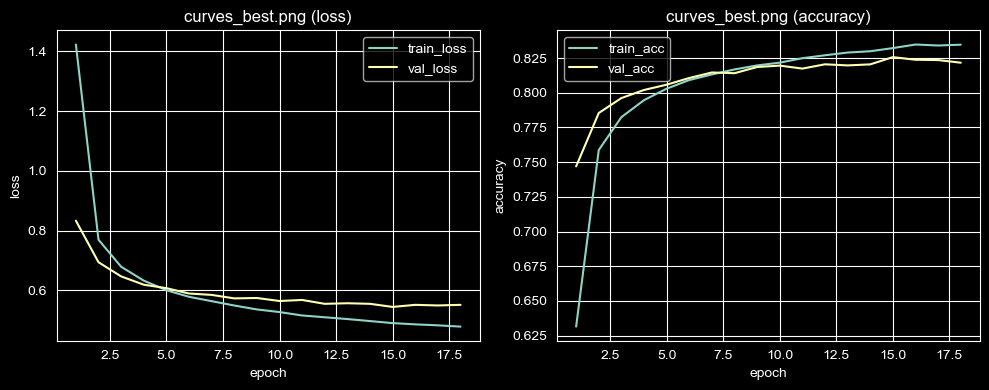

In [22]:
plot_curves_best(e4_baseline, title="curves_best.png")

In [23]:
def plot_curves_lr_extremes(history1: dict, history2: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs1 = np.arange(1, len(history1["train_loss"]) + 1)
    epochs2 = np.arange(1, len(history1["train_loss"]) + 1)

    plt.figure(figsize=(10, 8))

    plt.subplot(2, 2, 1)
    plt.plot(epochs1, history1["train_loss"], label="train_loss")
    plt.plot(epochs1, history1["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.plot(epochs1, history1["train_acc"], label="train_acc")
    plt.plot(epochs1, history1["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)


    plt.subplot(2, 2, 3)
    plt.plot(epochs2, history2["train_loss"], label="train_loss")
    plt.plot(epochs2, history2["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 2, 4)
    plt.plot(epochs2, history2["train_acc"], label="train_acc")
    plt.plot(epochs2, history2["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(
        f'artifacts/figures/{title}'
    )
    plt.show()

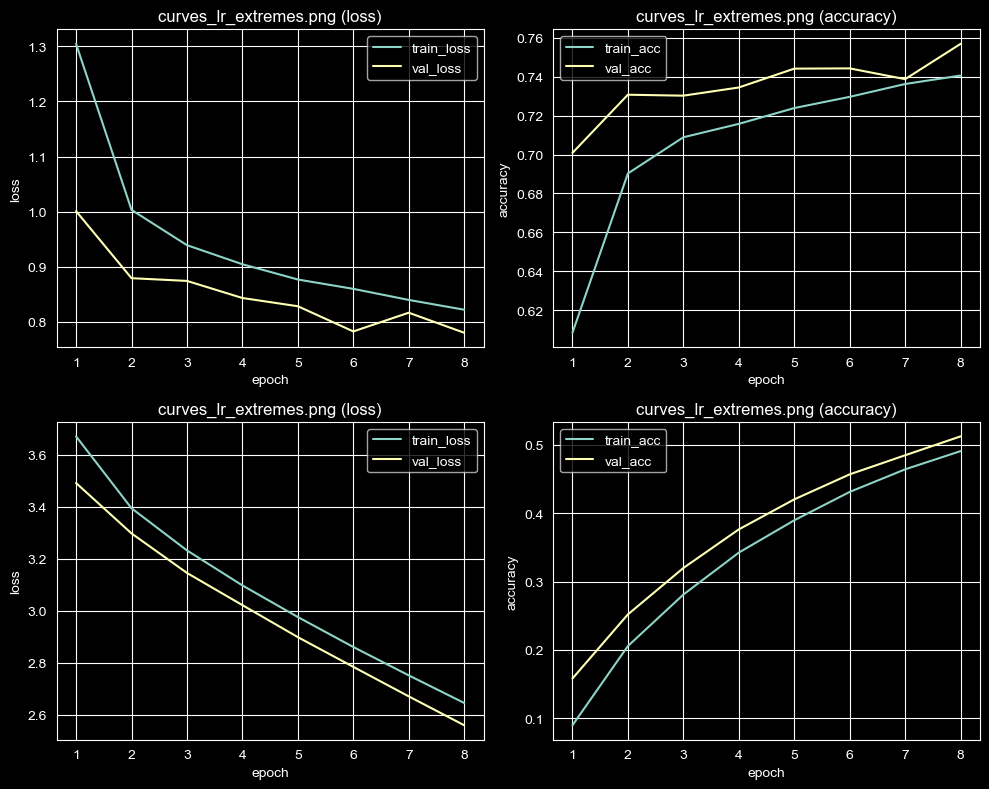

In [24]:
plot_curves_lr_extremes(o1_baseline, o2_baseline, title="curves_lr_extremes.png")